In [1]:
!pip install transformers torch scikit-learn pandas spacy
!python -m spacy download pt_core_news_lg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requ

In [2]:
import pandas as pd

caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv' 

# 1. Carregar o arquivo tabular usando latin-1 e separador de tabulação (\t)
df = pd.read_csv(caminho_arquivo, encoding='latin-1', sep='\t')

# 2. Juntar as colunas Título_Público e Descricao_pública em uma única coluna textual
df['texto_completo'] = df['Título_Público'].fillna('') + " - " + df['Descricao_pública'].fillna('')

df_amostra = df.copy() 

print("Dados carregados com sucesso! Exemplo do primeiro texto:")
print(df_amostra['texto_completo'].iloc[0])

Dados carregados com sucesso! Exemplo do primeiro texto:
Açúcar de frutas e aplicação em bolos como substituto da sacarose - O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contribui para os Objetivos de Desenvolvimento Sustentável (ODS) estabelecidos pela Organização das Nações Unidas (ONU) especialmente no âmbito do Objetivo 12 (Assegurar padrões de produção e de consumo sustentáveis). Diante desse cenário, a presenta proposta buscará desenvolver e produzir frutose em pó  que substitua a sacarose para atender o mercado de indústrias de alimentos.


In [3]:
import spacy

# 3. Identificar entidades nomeadas com spaCy (modelo pré-treinado)
nlp_base = spacy.load("pt_core_news_lg")

dados_treino = []

for texto in df_amostra['texto_completo']:
    doc = nlp_base(texto)
    entidades = []
    
    for ent in doc.ents:
        label = ent.label_
        
        # Correção do erro do modelo base: Forçar 'Brasil' a ser sempre 'LOC' (Localização)
        if ent.text.strip().lower() == 'brasil' and label != 'LOC':
            label = 'LOC'
            
        entidades.append((ent.start_char, ent.end_char, label))
    
    # Só adiciona o exemplo se tiver encontrado alguma entidade válida
    if entidades:
        dados_treino.append((texto, {"entities": entidades}))

print(f"Total de textos anotados automaticamente para treino: {len(dados_treino)}")

Total de textos anotados automaticamente para treino: 2147


In [4]:
import random
from spacy.training.example import Example

# 4. Treinar um modelo NER spaCy a partir das entidades identificadas
nlp_novo = spacy.blank("pt")
ner = nlp_novo.add_pipe("ner")

# Adiciona todas as categorias (LOC, PER, ORG, etc.) no novo modelo
for _, anotacoes in dados_treino:
    for ent in anotacoes.get("entities"):
        ner.add_label(ent[2])

# Iniciar o treinamento
optimizer = nlp_novo.begin_training()
epocas = 20 # Número de repetições do treino

print("Iniciando treinamento do modelo NER customizado...")
for itn in range(epocas):
    random.shuffle(dados_treino)
    losses = {}
    
    for texto, anotacoes in dados_treino:
        doc = nlp_novo.make_doc(texto)
        example = Example.from_dict(doc, anotacoes)
        nlp_novo.update([example], sgd=optimizer, drop=0.3, losses=losses)
        
    print(f"Época {itn+1} concluída - Loss (Erro): {losses['ner']:.4f}")

Iniciando treinamento do modelo NER customizado...
Época 1 concluída - Loss (Erro): 9777.7441
Época 2 concluída - Loss (Erro): 8083.2852
Época 3 concluída - Loss (Erro): 7618.9727
Época 4 concluída - Loss (Erro): 6986.7700
Época 5 concluída - Loss (Erro): 6781.6685
Época 6 concluída - Loss (Erro): 6169.0889
Época 7 concluída - Loss (Erro): 6080.2876
Época 8 concluída - Loss (Erro): 5819.6040
Época 9 concluída - Loss (Erro): 5830.4253
Época 10 concluída - Loss (Erro): 5478.8442
Época 11 concluída - Loss (Erro): 5104.5698
Época 12 concluída - Loss (Erro): 4953.7173
Época 13 concluída - Loss (Erro): 4796.0483
Época 14 concluída - Loss (Erro): 4686.4141
Época 15 concluída - Loss (Erro): 4523.1382
Época 16 concluída - Loss (Erro): 4354.4736
Época 17 concluída - Loss (Erro): 4089.4331
Época 18 concluída - Loss (Erro): 4085.6787
Época 19 concluída - Loss (Erro): 3876.7981
Época 20 concluída - Loss (Erro): 3882.9976


In [5]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

# 5. Gerar embeddings com BERTimbau
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Gerando embeddings usando: {device}")

# Carregar o BERTimbau
nome_modelo = 'neuralmind/bert-base-portuguese-cased'
tokenizer = AutoTokenizer.from_pretrained(nome_modelo)
modelo_bert = AutoModel.from_pretrained(nome_modelo).to(device)

def extrair_embeddings(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = modelo_bert(**inputs)
        
    # Média de todos os tokens para gerar 1 único vetor para a frase (Mean Pooling)
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embeddings.cpu().numpy()

# Aplica a função em todas as linhas
df_amostra['embeddings'] = df_amostra['texto_completo'].apply(extrair_embeddings)
print("Embeddings gerados!")

Gerando embeddings usando: cuda


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Embeddings gerados!


In [6]:
from sklearn.cluster import KMeans

# 6. Criar clusters de textos a partir dos embeddings
# Empilhar a lista de embeddings em uma matriz que o KMeans entende
matriz_embeddings = np.vstack(df_amostra['embeddings'].values)

num_clusters = 5 # Defina quantos agrupamentos você quer
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')

# Roda o algoritmo de clusterização
df_amostra['cluster'] = kmeans.fit_predict(matriz_embeddings)

print("Quantidade de textos em cada Cluster:")
print(df_amostra['cluster'].value_counts())

# Imprimir alguns exemplos do Cluster 0 para verificar se fez sentido
print("\n--- Exemplos do CLUSTER 0 ---")
textos_cluster_0 = df_amostra[df_amostra['cluster'] == 0]['texto_completo'].head(3).values
for texto in textos_cluster_0:
    print(f"-> {texto[:150]}...") # Mostra apenas o início do texto

Quantidade de textos em cada Cluster:
cluster
0    834
3    696
1    612
2    435
4    148
Name: count, dtype: int64

--- Exemplos do CLUSTER 0 ---
-> HUAWEI - PV generation with optimal BESS based on AI - Executar atividades de pesquisa e desenvolvimento de uma solução de gerenciamento ótimo de Arma...
-> HUAWEI SOLAR TRACKING CONTROL (AI BASED) - O Objetivo deste projeto consiste no desenvolvimento de um sistema baseado em Inteligência Artificial (IA) ...
-> Siemens-Energy - Análise dos dados coletados na indústria, estruturação, organização e validação do banco de dados das variáveis de interesse para cri...


In [7]:
print("--- TESTANDO A EXTRAÇÃO DE ENTIDADES DO MODELO TREINADO ---\n")

# 5 textos de amostra para testar
amostras_teste = df_amostra['texto_completo'].head(5).values

for texto in amostras_teste:
    # Passar o texto pelo nosso modelo recém-treinado
    doc = nlp_novo(texto)
    
    # Criar uma lista com o formato ('Texto da Entidade', 'LABEL')
    entidades_encontradas = [(ent.text, ent.label_) for ent in doc.ents]
    
    # Cortar o texto para não poluir muito a tela
    texto_exibicao = texto[:500]
    if len(texto) > 500:
        texto_exibicao += "..."
        
    print(f"TEXTO: {texto_exibicao}")
    print(f"ENTIDADES: {entidades_encontradas}")
    print("-" * 100)

--- TESTANDO A EXTRAÇÃO DE ENTIDADES DO MODELO TREINADO ---

TEXTO: Açúcar de frutas e aplicação em bolos como substituto da sacarose - O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contribui para os Objetivos de Desenvolvimento Sustentável (ODS) estabelecidos pela Organização das Nações Unidas (ONU) especialmente no âmbito do Objetivo 12 (Assegurar pa...
ENTIDADES: [('Brasil', 'LOC'), ('Objetivos de Desenvolvimento Sustentável', 'ORG'), ('ODS', 'ORG'), ('Organização das Nações Unidas', 'ORG'), ('ONU', 'ORG'), ('Objetivo 12', 'MISC')]
----------------------------------------------------------------------------------------------------
TEXTO: Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal - O uso de inovações tecnológicas auxilia as indús

Reduzindo a dimensionalidade de 768 para 2D usando PCA...


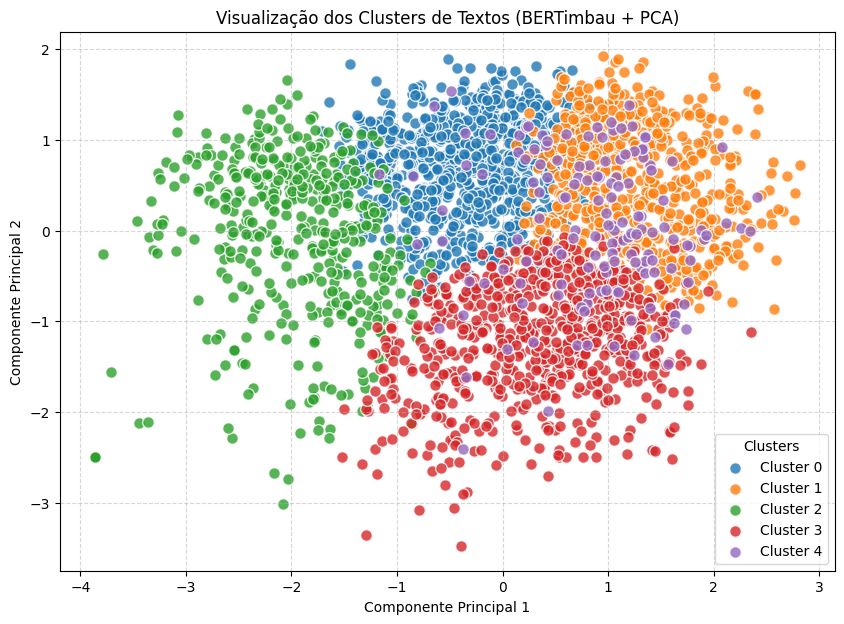

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Reduzindo a dimensionalidade de 768 para 2D usando PCA...")

# Usa a matriz de embeddings que já criada na Célula 6
pca = PCA(n_components=2, random_state=42)
pontos_2d = pca.fit_transform(matriz_embeddings)

# Cria um DataFrame temporário só para facilitar a plotagem do gráfico
plot_df = pd.DataFrame({
    "x": pontos_2d[:, 0],
    "y": pontos_2d[:, 1],
    "cluster": df_amostra["cluster"].astype(str),
})

# Configura o tamanho da imagem
plt.figure(figsize=(10, 7))

# Ordena os clusters para a legenda ficar na ordem certa (0, 1, 2, 3...)
clusters_ordenados = sorted(plot_df["cluster"].unique())

# Desenha os pontos de cada cluster separadamente com cores diferentes
for cluster_id in clusters_ordenados:
    subset = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(
        subset["x"], 
        subset["y"], 
        label=f"Cluster {cluster_id}", 
        alpha=0.8, 
        s=70, # Tamanho da bolinha
        edgecolors='w'
    )

# Textos e estilo do gráfico
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualização dos Clusters de Textos (BERTimbau + PCA)")
plt.legend(title="Clusters")
plt.grid(True, linestyle='--', alpha=0.5) # Adiciona a grade de fundo

# Exibe o gráfico
plt.show()